In [1]:
import matplotlib.patches as patches
import sys
sys.path.append("../src/")
from constrained_likelihood_surrogates import *

default_col_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

line_style_list = ['-', '--', '-.', ':', '-', (0, (3, 5, 1, 5, 1, 5))]
col_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:red', 'tab:gray', 'tab:olive', 'tab:cyan']

In [2]:
# # Load results

test_type = 'power'

load_folder_name = './results/hyp-test/benchmarking/'

N_list = [2**n for n in range(2, 11)]
# N_list = [2**n for n in range(2, 8)]
num_N = len(N_list)
N_tick_list = N_list[::4]

lower_cutoff = 1
num_surr = 19
num_tests = 10**3
# num_free_stats, num_depe_stats = 12, 3
# num_free_stats, num_depe_stats = 18, 7
# num_free_stats, num_depe_stats = 20, 3
num_free_stats, num_depe_stats = 20, 7
process_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
num_processes = len(process_list)
model_list = process_list
num_models = len(model_list)
# method_list = ['constrained', 'typical', 'sign', 'CLT']
method_list = ['constrained', 'typical']
num_methods = len(method_list)

free_quantile_mat = np.full((num_N, num_methods, num_processes, num_models, num_tests, num_free_stats), np.nan)#Array of nans: num_N x num_methods x num_processes x num_models x num_tests x num_free_stats
depe_quantile_mat = np.full((num_N, num_methods, num_processes, num_models, num_tests, num_depe_stats), np.nan)#Array of nans: num_N x num_methods x num_processes x num_models x num_tests x num_free_stats

process_str = '_p-1.5_l--1-1_e-1_t--1-1_u-9'

for i_N in range(num_N):
    N = N_list[i_N]
    num_trans = N*(int(np.ceil(np.log2(N*1024))))
    
    save_str_0 = 'quant_free-depe' + '_' + test_type + '_xmin-' + str(lower_cutoff) + '_N-' + str(N) + '_ntra-' + str(num_trans) + '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_npro-' + str(num_processes) + '_nmod-' + str(num_models) + '_nfs-' + str(num_free_stats) + '_nds-' + str(num_depe_stats)
    save_str = save_str_0 + process_str
    with open(load_folder_name + save_str + '.json', 'r') as read_file:
        save_dict = json.load(read_file)
    
    free_quantile_list_list_list = np.array(save_dict['free_quantile_list_list_list'])#num_methods x num_processes x num_models x num_tests x num_free_stats
    free_quantile_mat[i_N, :, :, :, :, :] = free_quantile_list_list_list# num_N x num_methods x num_processes x num_models x num_tests x num_free_stats
    
    depe_quantile_list_list_list = np.array(save_dict['depe_quantile_list_list_list'])#num_methods x num_processes x num_models x num_tests x num_depe_stats
    depe_quantile_mat[i_N, :, :, :, :, :] = depe_quantile_list_list_list# num_N x num_methods x num_processes x num_models x num_tests x num_depe_stats
    
    N = save_dict['N']
    num_trans = save_dict['num_trans']
    save_str = save_dict['save_str']
    depe_stat_name_list = save_dict['depe_stat_name_list']
    
test_type = save_dict['test_type']
lower_cutoff = save_dict['lower_cutoff']
num_surr = save_dict['num_surr']
num_tests = save_dict['num_tests']
num_methods = save_dict['num_methods']
process_list = save_dict['process_list']
model_list = save_dict['model_list']
free_stat_name_list = save_dict['free_stat_name_list']
depe_stat_name_list = save_dict['depe_stat_name_list']

nominal_size = 0.10

kL, kU = binom.interval(0.90, num_tests, nominal_size)
pL, pU = kL/num_tests, kU/num_tests

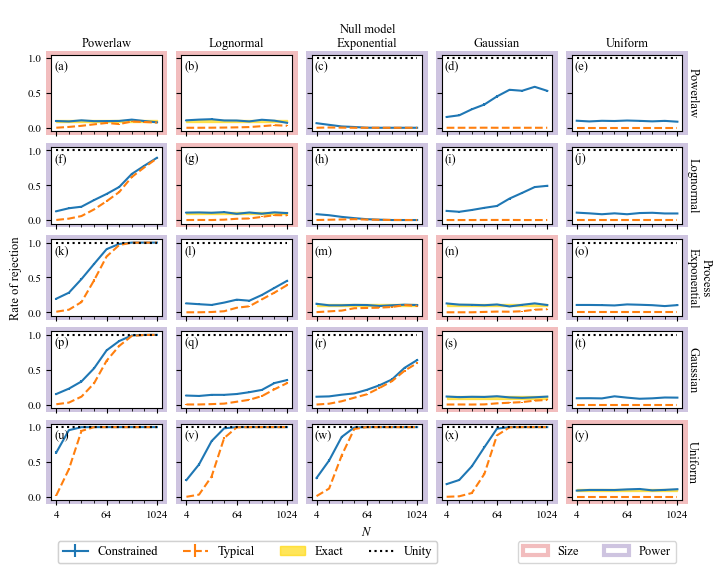

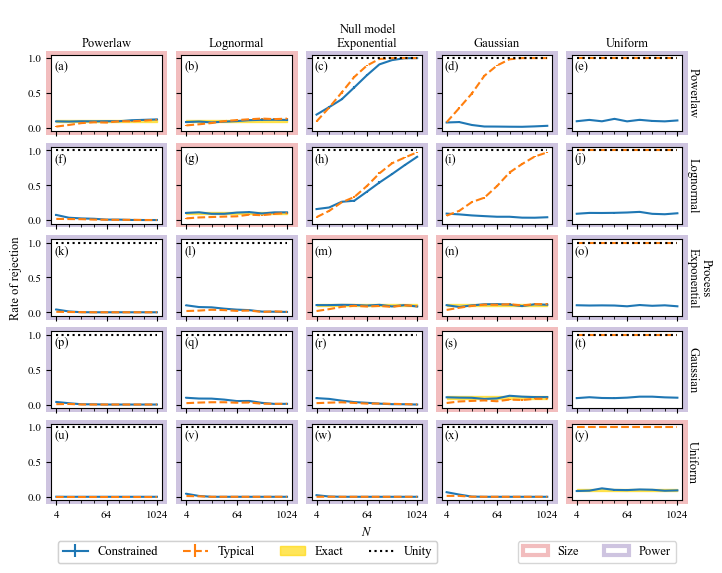

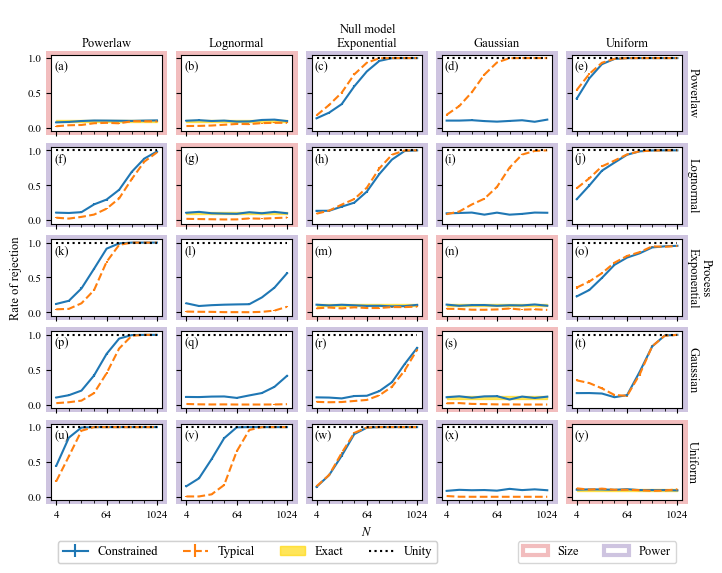

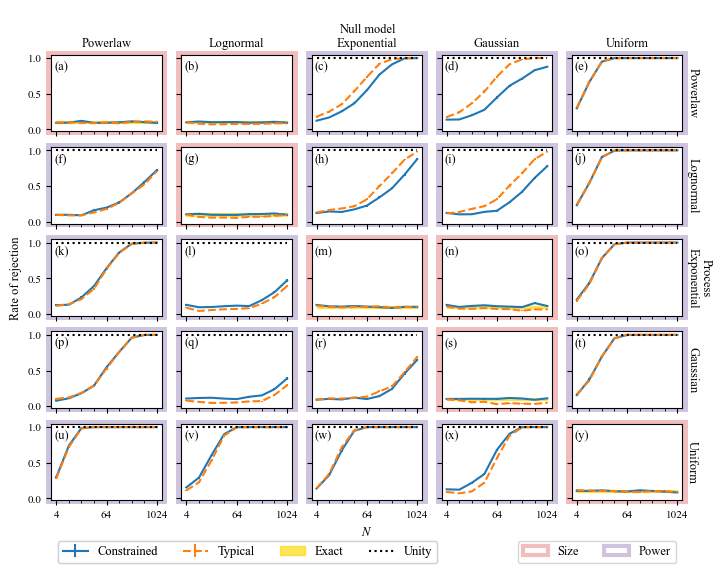

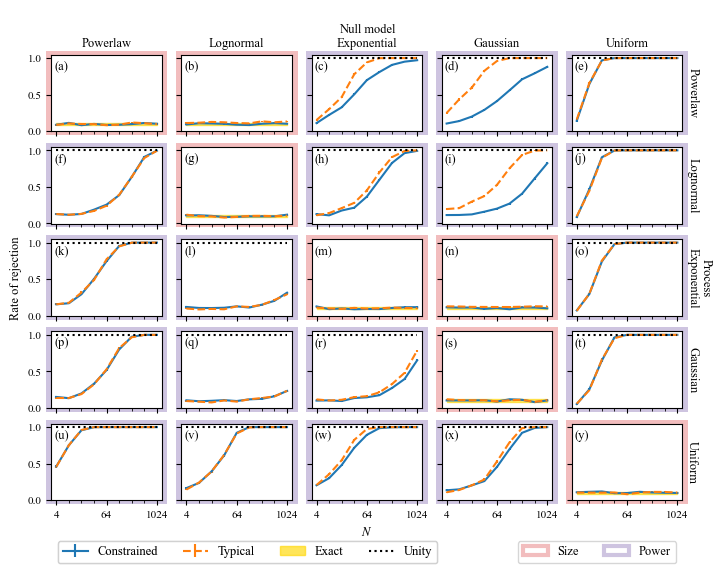

In [3]:
# process_list: ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']

# Plot POWER and SIZE:

# For coloured rectangle:
a_hori = 0.05;
a_vert = 0.05;
alph = 0.3
exact_alpha = 0.6
size_col = 'tab:red'#'#f28e8e'
power_col = '#5e3c99'#'tab:purple'#'#A89BBF'#grey-purple

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

stat_type_list = ['free', 'free', 'free', 'free', 'depe']#max, max, coef. var., skewness, KS
side_list = ['left-tailed', 'right-tailed', 'two-sided', 'two-sided', 'right-tailed']#max, max, coef. var., skewness, KS
i_stat_list = [4, 4, 6, 8, 0]#max, max, coef. var., skewness, KS
num_stats_to_consider = len(i_stat_list)

for i_stats_to_consider in range(num_stats_to_consider):
    stat_type = stat_type_list[i_stats_to_consider]
    i_stat = i_stat_list[i_stats_to_consider]
    side = side_list[i_stats_to_consider]
    
    if (stat_type == 'free'):
        stat_name_list = free_stat_name_list
        quantile_mat = free_quantile_mat
    elif (stat_type == 'depe'):
        stat_name_list = depe_stat_name_list
        quantile_mat = depe_quantile_mat
    num_stats = len(stat_name_list)
    
    if (side == 'left-tailed'):
        rej_mat = (quantile_mat < nominal_size)# num_N x num_methods x num_processes x num_models x num_tests x num_stats
    elif (side == 'right-tailed'):
        rej_mat = (quantile_mat > (1 - nominal_size))# num_N x num_methods x num_processes x num_models x num_tests x num_stats
    elif (side == 'two-sided'):
        rej_mat = ((quantile_mat > (1 - 0.5*nominal_size)) + (quantile_mat < 0.5*nominal_size))# num_N x num_methods x num_processes x num_models x num_tests x num_stats
        
    rej_rate_mat = np.sum(rej_mat, axis=4)/num_tests# num_N x num_methods x num_processes x num_models x num_free_stats
    
    stat = stat_name_list[i_stat]

    fig_width = 7.0
    fig, ax_array = plt.subplots(num_processes, num_models, sharex=True, sharey=True, figsize=(fig_width, num_processes))
    fig.tight_layout(pad=0.5)
    for i_process in range(num_processes):
        process = process_list[i_process]
        # ax_array[i_process][0].set_title(r'null model:                             ')
        meth_to_consider_list = [0, 1]
        #models_to_consider_list = list(set(range(num_models)).difference({i_process}))
        models_to_consider_list = list(range(num_models))
        for i_model in models_to_consider_list:
            model = model_list[i_model]
            ax = ax_array[i_process][i_model]
            for i_method in meth_to_consider_list:#['const.', 'typic.', 'sign', 'clt']
                method = method_list[i_method]
                method_name = beautify_method_name(method)
                rej_rate_list = rej_rate_mat[:, i_method, i_process, i_model, i_stat]
                err_list = np.sqrt(rej_rate_list*(1 - rej_rate_list)/num_tests)
                ax.errorbar(N_list, rej_rate_list, err_list, label=method_name, color=col_list[i_method], linestyle=line_style_list[i_method])
            if (i_process == 0):
                if (2*i_model + 1 == num_models):
                    ax.set_title('\nNull model\n' + beautify_distribution_name(model))
                else:
                    ax.set_title('\n' + beautify_distribution_name(model))
            if (i_model == 0) and (2*i_process + 1 == num_processes):
                ax.set_ylabel('Rate of rejection')
                # if (2*i_process + 1 == num_processes):
                #     ax.set_ylabel('process\n' + beautify_distribution_name(process) + '\n' + 'rate of rejection')
                # else:
                #     ax.set_ylabel('\n' + beautify_distribution_name(process) + '\n' + 'rate of rejection')
            if (i_model == (num_models - 1)):
                x = ax.get_position().x1 + 0.025#For right label
                y = (ax.get_position().y0 + ax.get_position().y1)/2#For right label
                if (2*i_process + 1 == num_processes):
                    fig.text(x, y, 'Process\n' + beautify_distribution_name(process), va='center', ha='center', rotation=270, fontsize=label_font_size)
                else:
                    fig.text(x, y, '\n' + beautify_distribution_name(process), va='center', ha='center', rotation=270, fontsize=label_font_size)
            if (i_model == i_process) or ([i_process, i_model] == [0, 1]) or ([i_process, i_model] == [2, 3]):
                ax.fill_between([min(N_list), max(N_list)], [pL, pL], [pU, pU], color='gold', alpha=exact_alpha, label='Exact')
                ax.errorbar([], [], linestyle=':', color='k', label='unity')
                panel_colour = size_col
            else:
                ax.fill_between([], [], [], color='gold', alpha=exact_alpha, label='Exact')
                ax.errorbar([min(N_list), max(N_list)], [1, 1], linestyle=':', color='k', label='Unity')
                panel_colour = power_col
            pos = ax.get_position()  # Bbox in *figure* coordinates
            rect = patches.Rectangle((pos.x0 - a_hori*pos.width, pos.y0 - a_vert*pos.width), pos.width + 2*a_hori*pos.width, pos.height + 2*a_vert*pos.width,
                                     transform=fig.transFigure, facecolor=panel_colour, alpha=alph, edgecolor='none', zorder=0, clip_on=False)
            fig.add_artist(rect)     # add to the figure background
            if (i_process == num_processes - 1) and (2*i_model + 1 == num_models):
                ax.set_xlabel('$N$')
        ax.set_xscale('log')
        ax.xaxis.set_minor_locator(LogLocator(base=2, numticks=num_N + 1))
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.set_xticks(N_tick_list)
        ax.set_xticklabels(N_tick_list)
        x_lim = [min(N_list)*(max(N_list)/min(N_list))**-0.05, max(N_list)*(max(N_list)/min(N_list))**+0.05]
        ax.set_xlim(x_lim)
    
    y_leg = -0.90
    ax = ax_array[num_processes - 1][0]
    ax.legend(ncol=4, loc='lower left', bbox_to_anchor=(0, -0.6))
    handles, labels = ax.get_legend_handles_labels()
    order = [1, 2, 0, 3]  # indices into handles/labels
    leg1 = ax.legend([handles[i] for i in order], [labels[i] for i in order], ncol=4, loc='lower left', bbox_to_anchor=(0, y_leg))
    ax.add_artist(leg1)
    ax = ax_array[num_processes - 1][num_models - 1]
    mpatches = [patches.Patch(facecolor='white', edgecolor=size_col, linewidth=3, alpha=alph, label='Size'), patches.Patch(facecolor='white', edgecolor=power_col, linewidth=3, alpha=0.3, label='Power')]
    leg2 = ax.legend(handles=mpatches, ncol=2, loc='lower right', bbox_to_anchor=(1, y_leg))
    
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    scale = fig.get_figwidth()/bbox.width
    fig.set_size_inches(fig.get_size_inches()*scale, forward=True)

    label_subplots(ax_array, corner='upper left', offset=(2, -4), order='row-major')
    
    fig_name_str = 'power-vs-N-from-' + stat + '_' + side + '_' + str(num_processes) + 'processes'
    plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')
    plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')
    plt.show()

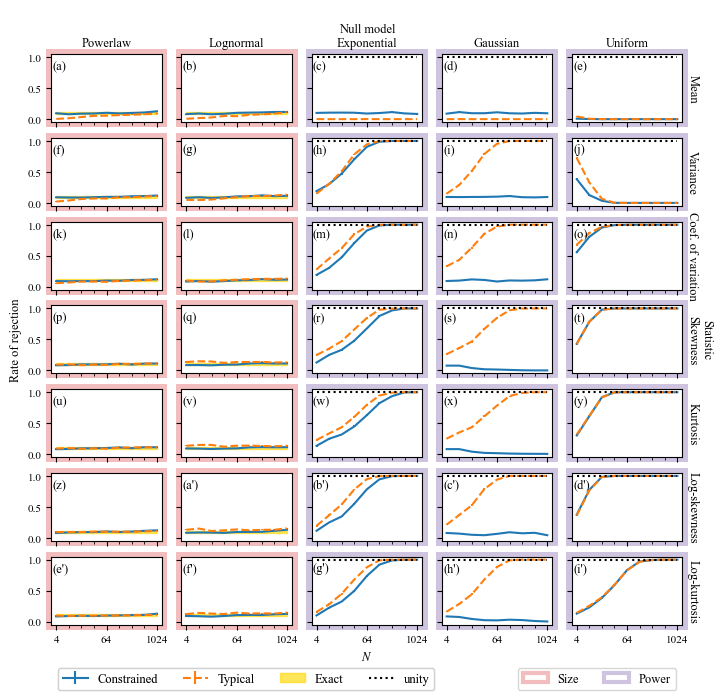

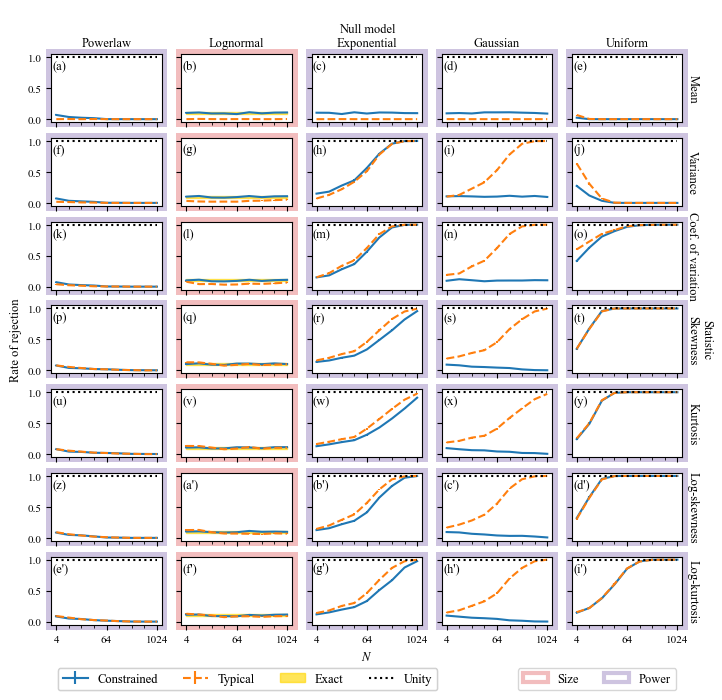

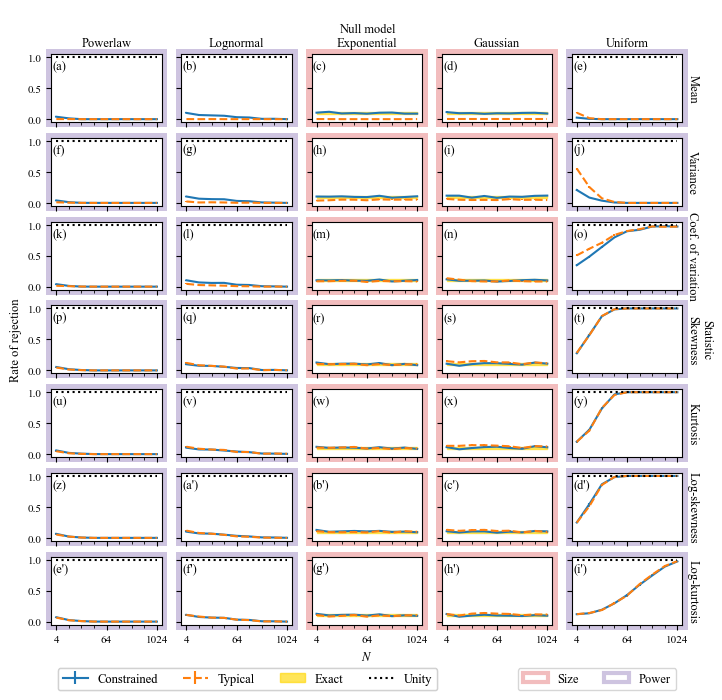

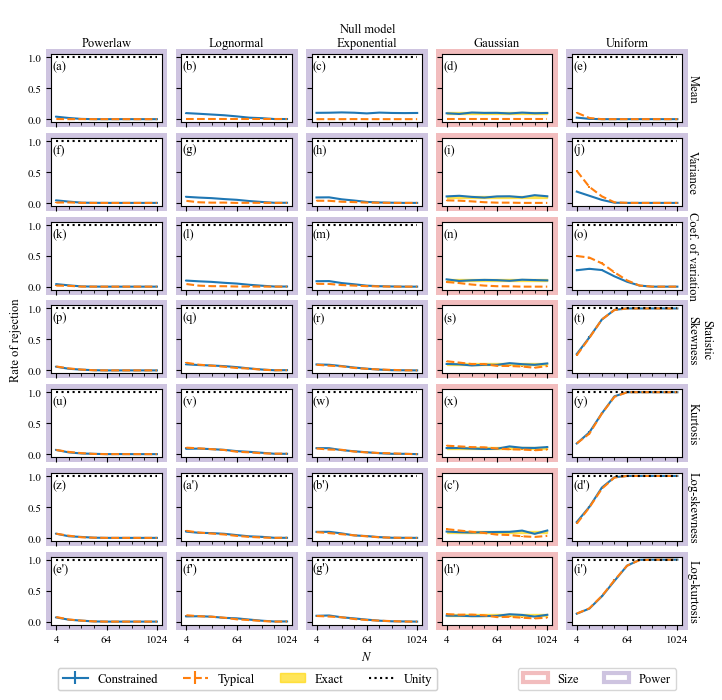

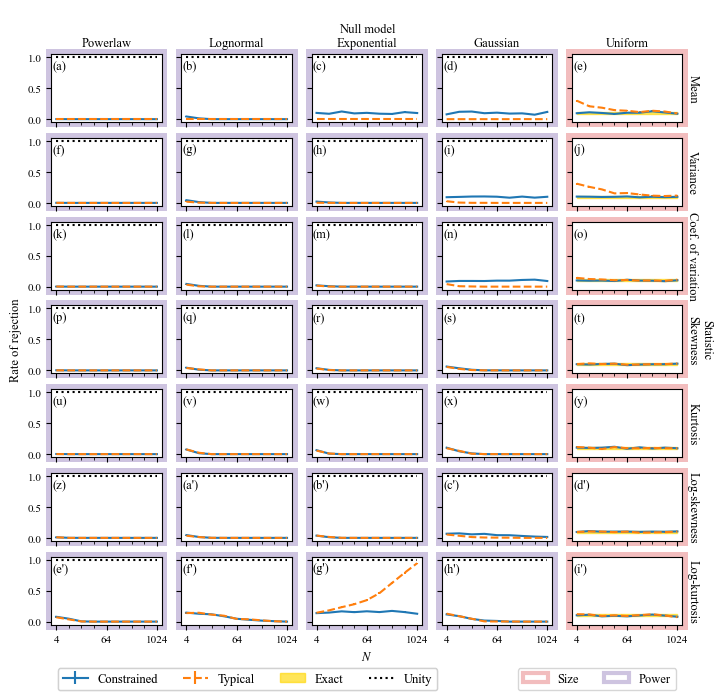

In [4]:
# process_list: ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']

# Plot POWER and SIZE:

# For coloured rectangle:
a_hori = 0.05;
a_vert = 0.05;
alph = 0.3
exact_alpha = 0.6
size_col = 'tab:red'#'#f28e8e'
power_col = '#5e3c99'#'tab:purple'#'#A89BBF'#grey-purple

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

stat_type = 'free'
# stat_type = 'depe'

# side = 'left-tailed'
side = 'right-tailed'
# side = 'two-sided'

if (stat_type == 'free'):
    stat_name_list = free_stat_name_list
    quantile_mat = free_quantile_mat
elif (stat_type == 'depe'):
    stat_name_list = depe_stat_name_list
    quantile_mat = depe_quantile_mat
num_stats = len(stat_name_list)

if (side == 'left-tailed'):
    rej_mat = (quantile_mat < nominal_size)# num_N x num_methods x num_processes x num_models x num_tests x num_stats
elif (side == 'right-tailed'):
    rej_mat = (quantile_mat > (1 - nominal_size))# num_N x num_methods x num_processes x num_models x num_tests x num_stats
elif (side == 'two-sided'):
    rej_mat = ((quantile_mat > (1 - 0.5*nominal_size)) + (quantile_mat < 0.5*nominal_size))# num_N x num_methods x num_processes x num_models x num_tests x num_stats
    
rej_rate_mat = np.sum(rej_mat, axis=4)/num_tests# num_N x num_methods x num_processes x num_models x num_free_stats

i_stats_to_consider_list = [0, 5, 6, 8, 9, 14, 15]#['mean_val', 'variance', 'coef_var', 'skew', 'kurtosis', 'log_skew', 'log_kurt']
num_stats_to_consider = len(i_stats_to_consider_list)

for i_process in range(num_processes):
    process = process_list[i_process]

    fig_width = 7.0
    fig, ax_array = plt.subplots(num_stats_to_consider, num_models, sharex=True, sharey=True, figsize=(fig_width, 0.9*num_stats_to_consider))
    fig.tight_layout(pad=0.5)
    for i_stats_to_consider in range(num_stats_to_consider):
        i_stat = i_stats_to_consider_list[i_stats_to_consider]
        stat = stat_name_list[i_stat]
        stat_name_full = beautify_stat_name(stat)
        meth_to_consider_list = [0, 1]
        models_to_consider_list = list(range(num_models))
        for i_model in models_to_consider_list:
            model = model_list[i_model]
            ax = ax_array[i_stats_to_consider][i_model]
            for i_method in meth_to_consider_list:#['const.', 'typic.', 'sign', 'clt']
                method = method_list[i_method]
                method_name = beautify_method_name(method)
                rej_rate_list = rej_rate_mat[:, i_method, i_process, i_model, i_stat]
                err_list = np.sqrt(rej_rate_list*(1 - rej_rate_list)/num_tests)
                ax.errorbar(N_list, rej_rate_list, err_list, label=method_name, color=col_list[i_method], linestyle=line_style_list[i_method])
            if (i_stats_to_consider == 0):
                if (2*i_model + 1 == num_models):
                    ax.set_title('\nNull model\n' + beautify_distribution_name(model))
                else:
                    ax.set_title('\n' + beautify_distribution_name(model))
            if (i_model == 0) and (2*i_stats_to_consider + 1 == num_stats_to_consider):
                ax.set_ylabel('Rate of rejection')
                # if (2*i_process + 1 == num_processes):
                #     ax.set_ylabel('process\n' + beautify_distribution_name(process) + '\n' + 'rate of rejection')
                # else:
                #     ax.set_ylabel('\n' + beautify_distribution_name(process) + '\n' + 'rate of rejection')
            if (i_model == (num_models - 1)):
                x = ax.get_position().x1 + 0.025#For right label
                y = (ax.get_position().y0 + ax.get_position().y1)/2#For right label
                if (2*i_stats_to_consider + 1 == num_stats_to_consider):
                    fig.text(x, y, 'Statistic\n' + stat_name_full, va='center', ha='center', rotation=270, fontsize=label_font_size)
                else:
                    fig.text(x, y, '\n' + stat_name_full, va='center', ha='center', rotation=270, fontsize=label_font_size)
            if (i_model == i_process) or ([i_process, i_model] == [0, 1]) or ([i_process, i_model] == [2, 3]):
                ax.fill_between([min(N_list), max(N_list)], [pL, pL], [pU, pU], color='gold', alpha=exact_alpha, label='Exact')
                ax.errorbar([], [], linestyle=':', color='k', label='unity')
                panel_colour = size_col
            else:
                ax.fill_between([], [], [], color='gold', alpha=exact_alpha, label='Exact')
                ax.errorbar([min(N_list), max(N_list)], [1, 1], linestyle=':', color='k', label='Unity')
                panel_colour = power_col
            pos = ax.get_position()  # Bbox in *figure* coordinates
            rect = patches.Rectangle((pos.x0 - a_hori*pos.width, pos.y0 - a_vert*pos.width), pos.width + 2*a_hori*pos.width, pos.height + 2*a_vert*pos.width,
                                     transform=fig.transFigure, facecolor=panel_colour, alpha=alph, edgecolor='none', zorder=0, clip_on=False)
            fig.add_artist(rect)     # add to the figure background
            if (i_stats_to_consider == num_stats_to_consider - 1) and (2*i_model + 1 == num_models):
                ax.set_xlabel('$N$')
        ax.set_xscale('log')
        ax.xaxis.set_minor_locator(LogLocator(base=2, numticks=num_N + 1))
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.set_xticks(N_tick_list)
        ax.set_xticklabels(N_tick_list)
        x_lim = [min(N_list)*(max(N_list)/min(N_list))**-0.05, max(N_list)*(max(N_list)/min(N_list))**+0.05]
        ax.set_xlim(x_lim)
    
    y_leg = -1.05
    ax = ax_array[num_stats_to_consider - 1][0]
    ax.legend(ncol=4, loc='lower left', bbox_to_anchor=(0, -0.6))
    handles, labels = ax.get_legend_handles_labels()
    order = [1, 2, 0, 3]  # indices into handles/labels
    leg1 = ax.legend([handles[i] for i in order], [labels[i] for i in order], ncol=4, loc='lower left', bbox_to_anchor=(0, y_leg))
    ax.add_artist(leg1)
    ax = ax_array[num_stats_to_consider - 1][num_models - 1]
    mpatches = [patches.Patch(facecolor='white', edgecolor=size_col, linewidth=3, alpha=alph, label='Size'), patches.Patch(facecolor='white', edgecolor=power_col, linewidth=3, alpha=0.3, label='Power')]
    leg2 = ax.legend(handles=mpatches, ncol=2, loc='lower right', bbox_to_anchor=(1, y_leg))

    label_subplots(ax_array, corner='upper left', offset=(1, -4), order='row-major')
    
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    scale = fig.get_figwidth()/bbox.width
    fig.set_size_inches(fig.get_size_inches()*scale, forward=True)
    
    fig_name_str = 'power-vs-N-from-' + str(num_stats_to_consider) + '-stats' + '_' + side + '_' + process
    plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')
    plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')
    plt.show()